# Labwork 2 - Supervised Learning

## Rain Prediction Classification using Two Weather Datasets

This notebook solves the supervised learning lab using two labeled weather datasets.  
The classification task is to predict whether it will rain tomorrow.

### Lab requirements

1. Find two datasets with labels.  
2. Split each dataset into training and test subsets.  
3. Run K-Nearest Neighbors (KNN).  
4. Calculate classification error, precision, recall, and F1-score.  
5. Vary the value of `k` and comment on the results.  
6. Normalize the input dataset and compare the performance.  
7. Repeat the experiment using Logistic Regression and SVM.

## 1. Import libraries

In [45]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

pd.set_option("display.max_columns", 100)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_curve, auc, roc_auc_score


## 2. Helper functions

The following functions are used for loading files, preprocessing data, training models, evaluating metrics, and plotting results.

In [46]:
def find_file(possible_names):
    """Find a CSV file in the current directory or Kaggle input directory."""
    search_roots = [".", "/kaggle/input"]
    for root in search_roots:
        if not os.path.exists(root):
            continue
        for dirname, _, filenames in os.walk(root):
            for filename in filenames:
                if filename in possible_names:
                    return os.path.join(dirname, filename)
    return None


def calculate_metrics(y_true, y_pred):
    """Calculate required classification metrics."""
    accuracy = accuracy_score(y_true, y_pred)
    return {
        "Accuracy": accuracy,
        "Classification Error": 1 - accuracy,
        "Precision": precision_score(y_true, y_pred, average="binary", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="binary", zero_division=0),
        "F1-score": f1_score(y_true, y_pred, average="binary", zero_division=0)
    }


def build_preprocessor(X, normalize=False):
    """Create preprocessing pipeline for numerical and categorical features."""
    numeric_features = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
    categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

    if normalize:
        numeric_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
    else:
        numeric_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median"))
        ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )
    return preprocessor


def train_and_evaluate(dataset_name, X, y, model_name, model, normalize=False):
    """Split data, train model, predict, and return metrics."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.3,
        random_state=42,
        stratify=y
    )

    pipeline = Pipeline(steps=[
        ("preprocessor", build_preprocessor(X_train, normalize=normalize)),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    metrics = calculate_metrics(y_test, y_pred)
    metrics.update({
        "Dataset": dataset_name,
        "Model": model_name,
        "Normalized": "Yes" if normalize else "No"
    })

    return metrics, y_test, y_pred


def plot_label_distribution(y, title):
    counts = y.value_counts().sort_index()
    labels = ["No rain", "Rain"]
    plt.figure(figsize=(6, 4))
    plt.bar(labels, counts.values)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Number of samples")
    plt.show()


def plot_knn_k_results(knn_df, dataset_name, metric="F1-score"):
    subset = knn_df[knn_df["Dataset"] == dataset_name]
    plt.figure(figsize=(8, 5))
    for normalized in ["No", "Yes"]:
        data = subset[subset["Normalized"] == normalized]
        plt.plot(data["k"], data[metric], marker="o", label=f"Normalized: {normalized}")
    plt.title(f"KNN performance with different k values - {dataset_name}")
    plt.xlabel("k value")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_model_comparison(results_df, dataset_name, metric="F1-score"):
    subset = results_df[results_df["Dataset"] == dataset_name].copy()
    subset["Model setting"] = subset["Model"] + " | Norm: " + subset["Normalized"]
    plt.figure(figsize=(10, 5))
    plt.bar(subset["Model setting"], subset[metric])
    plt.title(f"Model comparison by {metric} - {dataset_name}")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 3. Dataset 1: Australian Weather Rain Prediction

Dataset 1 uses `weatherAUS.csv`.  
The label is `RainTomorrow`, where:

- `No` is converted to `0`
- `Yes` is converted to `1`

A smaller stratified sample is used to make KNN and SVM run faster while preserving the class distribution.

In [47]:
aus_path = find_file(["weatherAUS.csv"])
print("Australian Weather Dataset path:", aus_path)

if aus_path is None:
    raise FileNotFoundError(
        "weatherAUS.csv was not found. Please upload weatherAUS.csv or add the Kaggle dataset to the notebook."
    )

weather_aus = pd.read_csv(aus_path)
print(weather_aus.shape)
weather_aus.head()

Australian Weather Dataset path: /kaggle/input/datasets/longtiucngsn/test-data/weatherAUS.csv
(145460, 23)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


Dataset 1 shape: (12000, 21)
Target distribution:
RainTomorrow
0    0.775833
1    0.224167
Name: proportion, dtype: float64


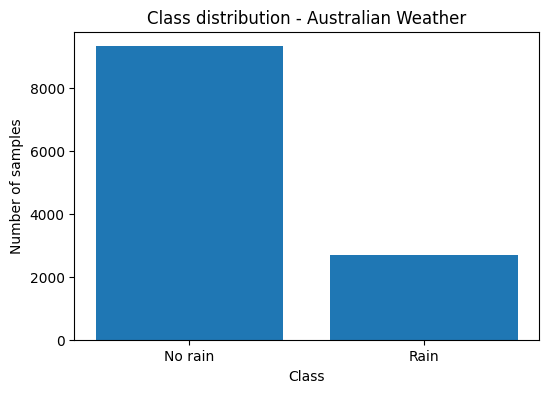

In [48]:
def prepare_weather_aus(df, sample_size=12000):
    df = df.copy()
    df = df.dropna(subset=["RainTomorrow"])
    df["RainTomorrow"] = df["RainTomorrow"].map({"No": 0, "Yes": 1})

    # Remove target and date column. Other columns are used as features.
    drop_cols = ["RainTomorrow", "Date"]

    sample_size = min(sample_size, len(df))
    if sample_size < len(df):
        df_sample, _ = train_test_split(
            df,
            train_size=sample_size,
            stratify=df["RainTomorrow"],
            random_state=42
        )
    else:
        df_sample = df.copy()

    X = df_sample.drop(columns=[c for c in drop_cols if c in df_sample.columns])
    y = df_sample["RainTomorrow"]
    return X, y

X_aus, y_aus = prepare_weather_aus(weather_aus)
print("Dataset 1 shape:", X_aus.shape)
print("Target distribution:")
print(y_aus.value_counts(normalize=True))
plot_label_distribution(y_aus, "Class distribution - Australian Weather")

## 4. Dataset 2: Seattle Weather Rain Prediction

Dataset 2 uses `seattle-weather.csv`.  
This dataset is also a weather classification problem. The original label is `weather`.  
For this lab, it is converted into a binary rain prediction target:

- `1`: weather is `rain` or `drizzle`
- `0`: other weather conditions such as `sun`, `fog`, or `snow`

To make the task similar to Dataset 1, the notebook creates `RainTomorrow` by shifting the binary rain label by one day. Therefore, the model uses today's weather variables to predict whether it will rain tomorrow.

In [49]:
seattle_path = find_file(["seattle-weather.csv", "seattle_weather.csv"])
print("Seattle Weather Dataset path:", seattle_path)

if seattle_path is None:
    raise FileNotFoundError(
        "seattle-weather.csv was not found. Please upload seattle-weather.csv or add the Seattle weather dataset to the notebook."
    )

weather_seattle = pd.read_csv(seattle_path)
print(weather_seattle.shape)
weather_seattle.head()

Seattle Weather Dataset path: /kaggle/input/datasets/longtiucngsn/test-data/seattle-weather.csv
(1461, 6)


,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


Dataset 2 shape: (1460, 4)
Target distribution:
RainTomorrow
0    0.525342
1    0.474658
Name: proportion, dtype: float64


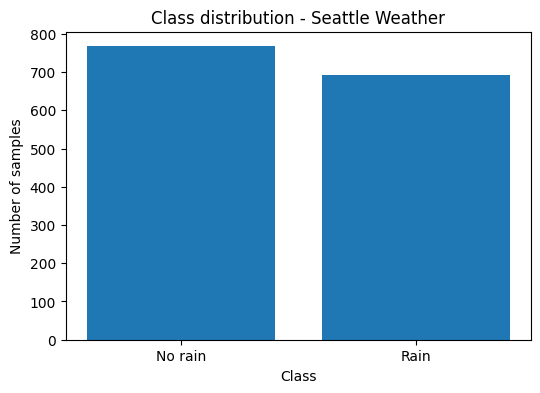

In [50]:
def prepare_seattle_weather(df):
    df = df.copy()

    # Standardize date column if available.
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])
        df = df.sort_values("date")

    # Convert original weather condition into binary rain label for the current day.
    df["RainTodayBinary"] = df["weather"].isin(["rain", "drizzle"]).astype(int)

    # Predict tomorrow's rain condition.
    df["RainTomorrow"] = df["RainTodayBinary"].shift(-1)
    df = df.dropna(subset=["RainTomorrow"])
    df["RainTomorrow"] = df["RainTomorrow"].astype(int)

    # Drop columns that would leak the target or are not useful for classification.
    drop_cols = ["RainTomorrow", "RainTodayBinary", "weather", "date"]
    X = df.drop(columns=[c for c in drop_cols if c in df.columns])
    y = df["RainTomorrow"]
    return X, y

X_seattle, y_seattle = prepare_seattle_weather(weather_seattle)
print("Dataset 2 shape:", X_seattle.shape)
print("Target distribution:")
print(y_seattle.value_counts(normalize=True))
plot_label_distribution(y_seattle, "Class distribution - Seattle Weather")

## 5. KNN experiments with different k values

The value of `k` is varied to observe how the KNN classifier changes its performance.  
Small values of `k` may overfit because the prediction depends on very few neighbors.  
Larger values of `k` may reduce overfitting, but if `k` becomes too large, the model may become too general and underfit.

In [51]:
datasets = {
    "Australian Weather": (X_aus, y_aus),
    "Seattle Weather": (X_seattle, y_seattle)
}

k_values = [1, 3, 5, 7, 9, 11, 15]
knn_results = []

for dataset_name, (X, y) in datasets.items():
    for k in k_values:
        for normalize in [False, True]:
            model = KNeighborsClassifier(n_neighbors=k)
            metrics, _, _ = train_and_evaluate(
                dataset_name=dataset_name,
                X=X,
                y=y,
                model_name="KNN",
                model=model,
                normalize=normalize
            )
            metrics["k"] = k
            knn_results.append(metrics)

knn_results_df = pd.DataFrame(knn_results)
knn_results_df[["Dataset", "Model", "k", "Normalized", "Accuracy", "Classification Error", "Precision", "Recall", "F1-score"]]

,Dataset,Model,k,Normalized,Accuracy,Classification Error,Precision,Recall,F1-score
0,Australian Weather,KNN,1,No,0.780833,0.219167,0.511658,0.489467,0.500317
1,Australian Weather,KNN,1,Yes,0.784722,0.215278,0.521220,0.486989,0.503523
2,Australian Weather,KNN,3,No,0.819722,0.180278,0.636207,0.457249,0.532084
3,Australian Weather,KNN,3,Yes,0.821389,0.178611,0.637124,0.472119,0.542349
4,Australian Weather,KNN,5,No,0.828333,0.171667,0.675325,0.451053,0.540862
5,Australian Weather,KNN,5,Yes,0.829722,0.170278,0.677007,0.459727,0.547601
6,Australian Weather,KNN,7,No,0.831667,0.168333,0.695146,0.443618,0.541604
7,Australian Weather,KNN,7,Yes,0.833333,0.166667,0.706587,0.438662,0.541284
8,Australian Weather,KNN,9,No,0.834722,0.165278,0.713710,0.438662,0.543361
9,Australian Weather,KNN,9,Yes,0.834722,0.165278,0.719917,0.429988,0.538402


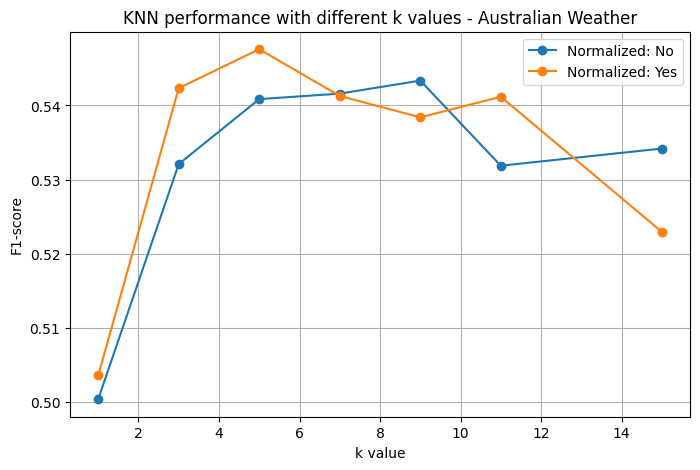

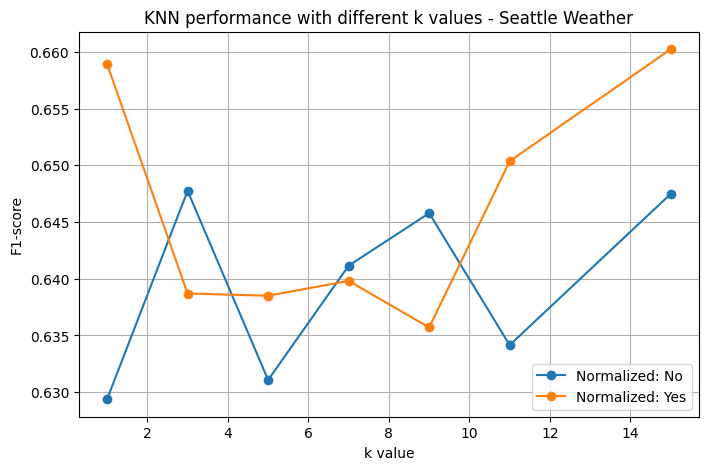

In [52]:
for dataset_name in datasets.keys():
    plot_knn_k_results(knn_results_df, dataset_name, metric="F1-score")

### Comments on KNN results

For KNN, changing `k` affects the bias-variance trade-off.  
When `k = 1`, the model can be sensitive to noise because each prediction is based on only the nearest sample.  
As `k` increases, the classifier becomes more stable. However, if `k` is too large, the model may become less sensitive to local patterns.

Normalization is especially important for KNN because it relies on distance calculation. Features with larger scales can dominate the distance if the data is not normalized. Therefore, normalized KNN is usually expected to perform better or more consistently than non-normalized KNN.

## 6. Logistic Regression and SVM experiments

The same train/test split and evaluation metrics are used for Logistic Regression and SVM.  
Each model is evaluated twice:

1. Without normalization  
2. With normalization

In [53]:
all_results = []

# Add best KNN result for each dataset and normalization setting.
for dataset_name in datasets.keys():
    for normalize_label in ["No", "Yes"]:
        subset = knn_results_df[
            (knn_results_df["Dataset"] == dataset_name) &
            (knn_results_df["Normalized"] == normalize_label)
        ]
        best_row = subset.sort_values("F1-score", ascending=False).iloc[0].copy()
        best_row["Model"] = f"KNN best k={int(best_row['k'])}"
        all_results.append(best_row.to_dict())

# Logistic Regression and SVM
for dataset_name, (X, y) in datasets.items():
    experiments = [
        ("Logistic Regression", LogisticRegression(max_iter=1000)),
        ("SVM", SVC(kernel="rbf", random_state=42))
    ]

    for model_name, model in experiments:
        for normalize in [False, True]:
            metrics, _, _ = train_and_evaluate(
                dataset_name=dataset_name,
                X=X,
                y=y,
                model_name=model_name,
                model=model,
                normalize=normalize
            )
            all_results.append(metrics)

results_df = pd.DataFrame(all_results)
results_df = results_df[["Dataset", "Model", "Normalized", "Accuracy", "Classification Error", "Precision", "Recall", "F1-score"]]
results_df

,Dataset,Model,Normalized,Accuracy,Classification Error,Precision,Recall,F1-score
0,Australian Weather,KNN best k=9,No,0.834722,0.165278,0.713710,0.438662,0.543361
1,Australian Weather,KNN best k=5,Yes,0.829722,0.170278,0.677007,0.459727,0.547601
2,Seattle Weather,KNN best k=3,No,0.659817,0.340183,0.637209,0.658654,0.647754
3,Seattle Weather,KNN best k=15,Yes,0.678082,0.321918,0.661836,0.658654,0.660241
4,Australian Weather,Logistic Regression,No,0.839444,0.160556,0.708561,0.482032,0.573746
5,Australian Weather,Logistic Regression,Yes,0.845556,0.154444,0.718261,0.511772,0.597685
6,Australian Weather,SVM,No,0.776389,0.223611,1.000000,0.002478,0.004944
7,Australian Weather,SVM,Yes,0.850278,0.149722,0.774590,0.468401,0.583784
8,Seattle Weather,Logistic Regression,No,0.700913,0.299087,0.708108,0.629808,0.666667
9,Seattle Weather,Logistic Regression,Yes,0.700913,0.299087,0.710383,0.625000,0.664962


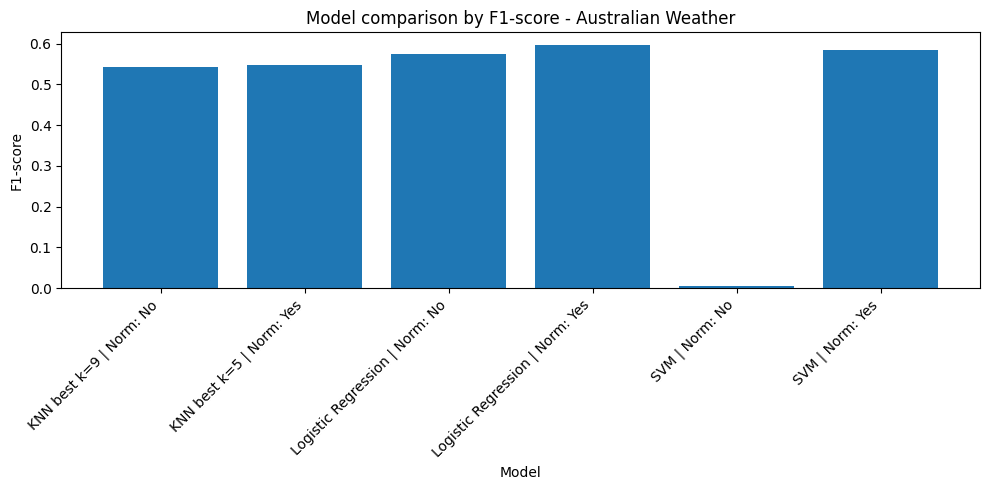

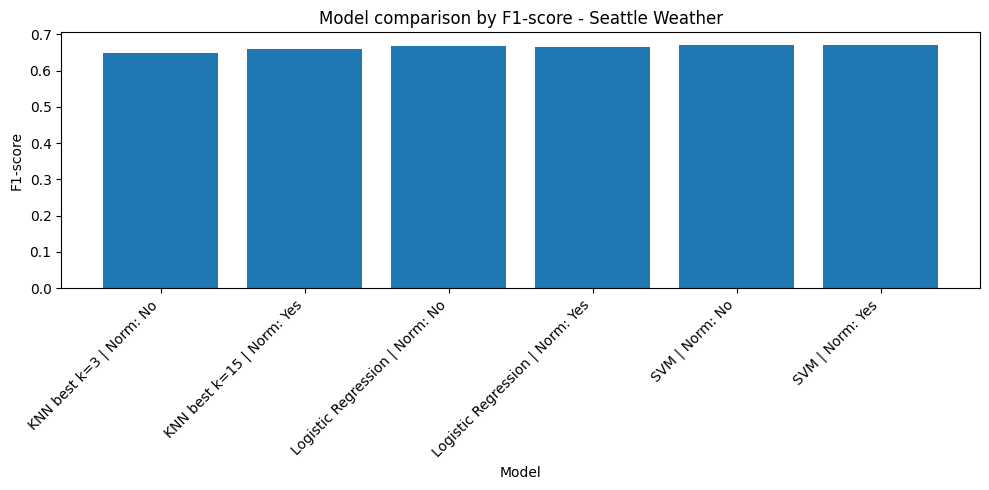

In [54]:
for dataset_name in datasets.keys():
    plot_model_comparison(results_df, dataset_name, metric="F1-score")

## 7. Confusion matrix and classification report for the best model

The following cell selects the best model by F1-score for each dataset and prints the confusion matrix and classification report.  
This is useful for academic reporting because it shows how many rain/no-rain cases were correctly and incorrectly classified.

In [55]:
def get_model_from_name(model_name):
    if model_name.startswith("KNN"):
        k = int(model_name.split("=")[1])
        return KNeighborsClassifier(n_neighbors=k)
    if model_name == "Logistic Regression":
        return LogisticRegression(max_iter=1000)
    if model_name == "SVM":
        return SVC(kernel="rbf", random_state=42)
    raise ValueError("Unknown model name")

for dataset_name, (X, y) in datasets.items():
    best = results_df[results_df["Dataset"] == dataset_name].sort_values("F1-score", ascending=False).iloc[0]
    model = get_model_from_name(best["Model"])
    normalize = best["Normalized"] == "Yes"

    metrics, y_test, y_pred = train_and_evaluate(
        dataset_name=dataset_name,
        X=X,
        y=y,
        model_name=best["Model"],
        model=model,
        normalize=normalize
    )

    print("=" * 80)
    print(f"Best model for {dataset_name}: {best['Model']} | Normalized: {best['Normalized']}")
    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Classification report:")
    print(classification_report(y_test, y_pred, target_names=["No rain", "Rain"], zero_division=0))

Best model for Australian Weather: Logistic Regression | Normalized: Yes
Confusion matrix:
[[2631  162]
 [ 394  413]]
Classification report:
              precision    recall  f1-score   support

     No rain       0.87      0.94      0.90      2793
        Rain       0.72      0.51      0.60       807

    accuracy                           0.85      3600
   macro avg       0.79      0.73      0.75      3600
weighted avg       0.84      0.85      0.84      3600

Best model for Seattle Weather: SVM | Normalized: No
Confusion matrix:
[[181  49]
 [ 78 130]]
Classification report:
              precision    recall  f1-score   support

     No rain       0.70      0.79      0.74       230
        Rain       0.73      0.62      0.67       208

    accuracy                           0.71       438
   macro avg       0.71      0.71      0.71       438
weighted avg       0.71      0.71      0.71       438



### 7.1 Confusion Matrix Analysis of Best Baseline Models

The following table summarizes the confusion matrix values of the best baseline model for each dataset. The best baseline model is selected according to the highest test F1-score from the baseline comparison table. This table can be used in the report before the tuned-model analysis.


In [56]:
# Confusion Matrix Analysis of Best Baseline Models
# This table summarizes the best baseline model selected from results_df by F1-score.

from IPython.display import display

baseline_confusion_rows = []

for dataset_name, (X, y) in datasets.items():
    # Select the best baseline model for each dataset using the highest F1-score.
    best_baseline = (
        results_df[results_df["Dataset"] == dataset_name]
        .sort_values("F1-score", ascending=False)
        .iloc[0]
    )

    model = get_model_from_name(best_baseline["Model"])
    normalize = best_baseline["Normalized"] == "Yes"

    metrics, y_test, y_pred = train_and_evaluate(
        dataset_name=dataset_name,
        X=X,
        y=y,
        model_name=best_baseline["Model"],
        model=model,
        normalize=normalize
    )

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    baseline_confusion_rows.append({
        "Dataset": dataset_name,
        "Best Baseline Model": best_baseline["Model"],
        "Normalized": best_baseline["Normalized"],
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Accuracy": metrics["Accuracy"],
        "Classification Error": metrics["Classification Error"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "F1-score": metrics["F1-score"]
    })

baseline_confusion_df = pd.DataFrame(baseline_confusion_rows)

print("Confusion Matrix Analysis of Best Baseline Models")
display(baseline_confusion_df)


Confusion Matrix Analysis of Best Baseline Models


,Dataset,Best Baseline Model,Normalized,TN,FP,FN,TP,Accuracy,Classification Error,Precision,Recall,F1-score
0,Australian Weather,Logistic Regression,Yes,2631,162,394,413,0.845556,0.154444,0.718261,0.511772,0.597685
1,Seattle Weather,SVM,No,181,49,78,130,0.710046,0.289954,0.726257,0.625000,0.671835


## 8. Summary table

This table summarizes the main experimental results. The most important metrics for this binary classification task are classification error, precision, recall, and F1-score.

In [57]:
summary_table = results_df.sort_values(["Dataset", "F1-score"], ascending=[True, False])
summary_table

,Dataset,Model,Normalized,Accuracy,Classification Error,Precision,Recall,F1-score
5,Australian Weather,Logistic Regression,Yes,0.845556,0.154444,0.718261,0.511772,0.597685
7,Australian Weather,SVM,Yes,0.850278,0.149722,0.774590,0.468401,0.583784
4,Australian Weather,Logistic Regression,No,0.839444,0.160556,0.708561,0.482032,0.573746
1,Australian Weather,KNN best k=5,Yes,0.829722,0.170278,0.677007,0.459727,0.547601
0,Australian Weather,KNN best k=9,No,0.834722,0.165278,0.713710,0.438662,0.543361
6,Australian Weather,SVM,No,0.776389,0.223611,1.000000,0.002478,0.004944
10,Seattle Weather,SVM,No,0.710046,0.289954,0.726257,0.625000,0.671835
11,Seattle Weather,SVM,Yes,0.710046,0.289954,0.726257,0.625000,0.671835
8,Seattle Weather,Logistic Regression,No,0.700913,0.299087,0.708108,0.629808,0.666667
9,Seattle Weather,Logistic Regression,Yes,0.700913,0.299087,0.710383,0.625000,0.664962


## 9. Additional hyperparameter tuning, ROC-AUC, and Cross Validation

The previous sections satisfy the original lab requirements. This section improves the academic quality of the notebook by adding:

1. Logistic Regression hyperparameter tuning using different values of `C`.
2. SVM hyperparameter tuning using different values of `C` and `gamma`.
3. ROC Curve and AUC analysis for the best KNN, Logistic Regression, and SVM models.
4. Stratified k-fold Cross Validation to evaluate model stability.

These additions show not only the final model performance, but also the process used to select model configurations.


In [58]:
# Additional helper functions for tuning, ROC-AUC, and cross validation

def evaluate_pipeline_once(dataset_name, X, y, model_name, model, normalize=True):
    """Train/test evaluation for a single model configuration."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.3,
        random_state=42,
        stratify=y
    )

    pipeline = Pipeline(steps=[
        ("preprocessor", build_preprocessor(X_train, normalize=normalize)),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    metrics = calculate_metrics(y_test, y_pred)
    metrics.update({
        "Dataset": dataset_name,
        "Model": model_name,
        "Normalized": "Yes" if normalize else "No"
    })
    return metrics, pipeline, X_test, y_test, y_pred


def get_score_values(pipeline, X_test):
    """Return continuous scores for ROC curve."""
    clf = pipeline.named_steps["classifier"]
    if hasattr(clf, "predict_proba"):
        return pipeline.predict_proba(X_test)[:, 1]
    if hasattr(clf, "decision_function"):
        return pipeline.decision_function(X_test)
    return pipeline.predict(X_test)


def plot_logistic_tuning(logistic_df, dataset_name):
    subset = logistic_df[logistic_df["Dataset"] == dataset_name].sort_values("C")
    plt.figure(figsize=(8, 5))
    plt.plot(subset["C"], subset["F1-score"], marker="o")
    plt.xscale("log")
    plt.title(f"Logistic Regression tuning by C - {dataset_name}")
    plt.xlabel("C value (log scale)")
    plt.ylabel("F1-score")
    plt.grid(True)
    plt.show()


def plot_svm_heatmap(svm_df, dataset_name):
    subset = svm_df[svm_df["Dataset"] == dataset_name].copy()
    pivot = subset.pivot(index="gamma", columns="C", values="F1-score")

    plt.figure(figsize=(7, 5))
    plt.imshow(pivot.values, aspect="auto")
    plt.title(f"SVM RBF tuning heatmap - {dataset_name}")
    plt.xlabel("C value")
    plt.ylabel("gamma")
    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.colorbar(label="F1-score")

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            plt.text(j, i, f"{pivot.values[i, j]:.3f}", ha="center", va="center")

    plt.tight_layout()
    plt.show()


### 9.1 Logistic Regression hyperparameter tuning

For Logistic Regression, the main hyperparameter tested is `C`, which controls the inverse strength of regularization. Smaller `C` means stronger regularization, while larger `C` means weaker regularization. The F1-score is used to select the best value because rainfall prediction can be affected by class imbalance.


In [59]:
# Logistic Regression tuning: F1-score by C
logistic_C_values = [0.001, 0.01, 0.1, 1, 10, 100]
logistic_tuning_results = []

for dataset_name, (X, y) in datasets.items():
    for C in logistic_C_values:
        model = LogisticRegression(C=C, max_iter=2000, random_state=42)
        metrics, _, _, _, _ = evaluate_pipeline_once(
            dataset_name=dataset_name,
            X=X,
            y=y,
            model_name="Logistic Regression",
            model=model,
            normalize=True
        )
        metrics["C"] = C
        logistic_tuning_results.append(metrics)

logistic_tuning_df = pd.DataFrame(logistic_tuning_results)
logistic_tuning_df[["Dataset", "C", "Accuracy", "Classification Error", "Precision", "Recall", "F1-score"]]


,Dataset,C,Accuracy,Classification Error,Precision,Recall,F1-score
0,Australian Weather,0.001,0.828333,0.171667,0.760331,0.342007,0.471795
1,Australian Weather,0.010,0.841111,0.158889,0.729941,0.462206,0.566009
2,Australian Weather,0.100,0.843056,0.156944,0.715302,0.498141,0.587290
3,Australian Weather,1.000,0.845556,0.154444,0.718261,0.511772,0.597685
4,Australian Weather,10.000,0.846944,0.153056,0.721453,0.516729,0.602166
5,Australian Weather,100.000,0.846667,0.153333,0.720971,0.515489,0.601156
6,Seattle Weather,0.001,0.623288,0.376712,0.697248,0.365385,0.479495
7,Seattle Weather,0.010,0.684932,0.315068,0.708333,0.572115,0.632979
8,Seattle Weather,0.100,0.700913,0.299087,0.715084,0.615385,0.661499
9,Seattle Weather,1.000,0.700913,0.299087,0.710383,0.625000,0.664962


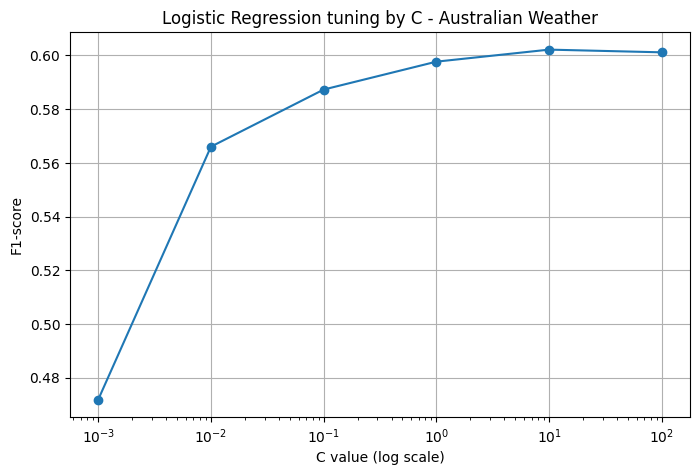

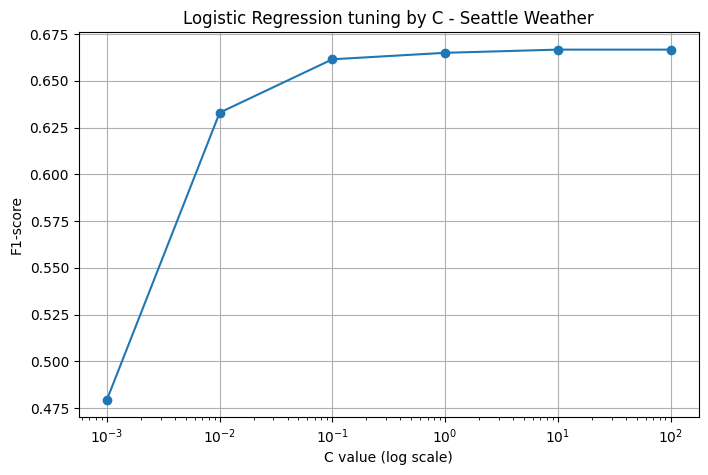

Best Logistic Regression settings by dataset:


,Dataset,C,Accuracy,Classification Error,Precision,Recall,F1-score
11,Seattle Weather,100.0,0.700913,0.299087,0.708108,0.629808,0.666667
4,Australian Weather,10.0,0.846944,0.153056,0.721453,0.516729,0.602166


In [60]:
for dataset_name in datasets.keys():
    plot_logistic_tuning(logistic_tuning_df, dataset_name)

print("Best Logistic Regression settings by dataset:")
logistic_best_df = logistic_tuning_df.sort_values("F1-score", ascending=False).groupby("Dataset").head(1)
logistic_best_df[["Dataset", "C", "Accuracy", "Classification Error", "Precision", "Recall", "F1-score"]]


### 9.2 SVM hyperparameter tuning

For SVM with RBF kernel, two important hyperparameters are tuned:

- `C`: controls the trade-off between margin size and classification error.
- `gamma`: controls the influence range of each training sample.

The heatmap below shows how different combinations of `C` and `gamma` affect the F1-score.


In [61]:
# SVM RBF tuning: F1-score heatmap for C and gamma
# Note: SVM can be slower than Logistic Regression, so this grid is intentionally compact.
svm_C_values = [0.1, 1, 10]
svm_gamma_values = ["scale", 0.01, 0.1]
svm_tuning_results = []

for dataset_name, (X, y) in datasets.items():
    for C in svm_C_values:
        for gamma in svm_gamma_values:
            model = SVC(kernel="rbf", C=C, gamma=gamma, random_state=42)
            metrics, _, _, _, _ = evaluate_pipeline_once(
                dataset_name=dataset_name,
                X=X,
                y=y,
                model_name="SVM RBF",
                model=model,
                normalize=True
            )
            metrics["C"] = C
            metrics["gamma"] = str(gamma)
            svm_tuning_results.append(metrics)

svm_tuning_df = pd.DataFrame(svm_tuning_results)
svm_tuning_df[["Dataset", "C", "gamma", "Accuracy", "Classification Error", "Precision", "Recall", "F1-score"]]


,Dataset,C,gamma,Accuracy,Classification Error,Precision,Recall,F1-score
0,Australian Weather,0.1,scale,0.838889,0.161111,0.785894,0.386617,0.518272
1,Australian Weather,0.1,0.01,0.833056,0.166944,0.764103,0.369269,0.497911
2,Australian Weather,0.1,0.1,0.826944,0.173056,0.817241,0.293680,0.432088
3,Australian Weather,1.0,scale,0.850278,0.149722,0.774590,0.468401,0.583784
4,Australian Weather,1.0,0.01,0.842500,0.157500,0.765487,0.428748,0.549643
5,Australian Weather,1.0,0.1,0.850000,0.150000,0.760234,0.483271,0.590909
6,Australian Weather,10.0,scale,0.832500,0.167500,0.657895,0.526642,0.584997
7,Australian Weather,10.0,0.01,0.848611,0.151389,0.768443,0.464684,0.579151
8,Australian Weather,10.0,0.1,0.831667,0.168333,0.644604,0.555143,0.596538
9,Seattle Weather,0.1,scale,0.675799,0.324201,0.650000,0.687500,0.668224


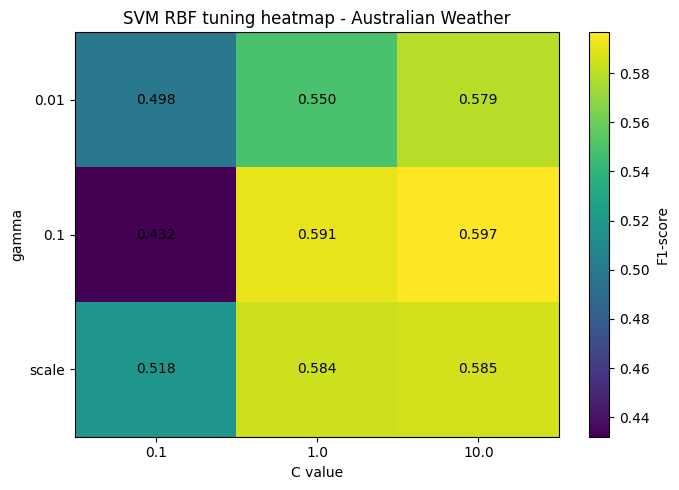

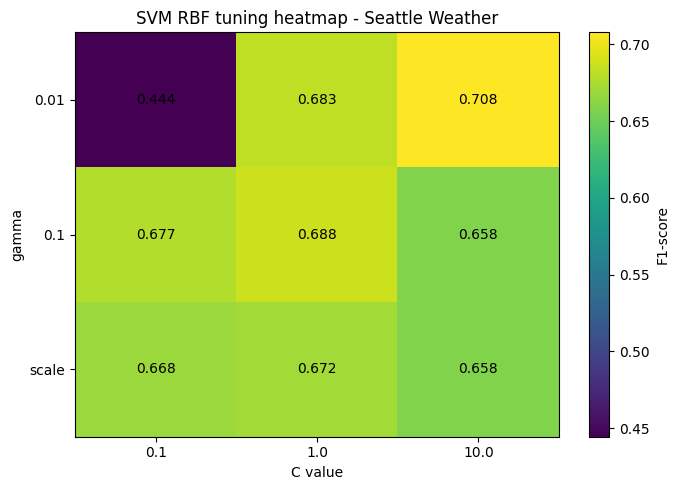

Best SVM settings by dataset:


,Dataset,C,gamma,Accuracy,Classification Error,Precision,Recall,F1-score
16,Seattle Weather,10.0,0.01,0.730594,0.269406,0.729592,0.687500,0.707921
8,Australian Weather,10.0,0.1,0.831667,0.168333,0.644604,0.555143,0.596538


In [62]:
for dataset_name in datasets.keys():
    plot_svm_heatmap(svm_tuning_df, dataset_name)

print("Best SVM settings by dataset:")
svm_best_df = svm_tuning_df.sort_values("F1-score", ascending=False).groupby("Dataset").head(1)
svm_best_df[["Dataset", "C", "gamma", "Accuracy", "Classification Error", "Precision", "Recall", "F1-score"]]


### 9.3 ROC Curve and AUC analysis

ROC Curve evaluates the trade-off between True Positive Rate and False Positive Rate. AUC summarizes the overall ranking quality of a classifier. Higher AUC indicates stronger ability to separate rain and no-rain classes.

The following plots compare the best KNN, tuned Logistic Regression, and tuned SVM models on each dataset.


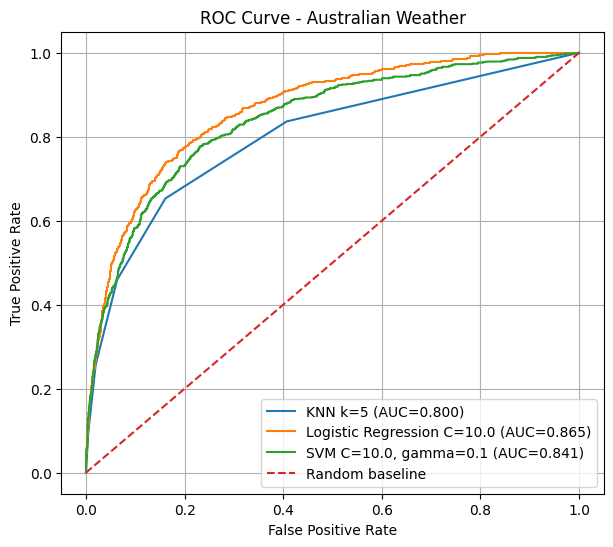

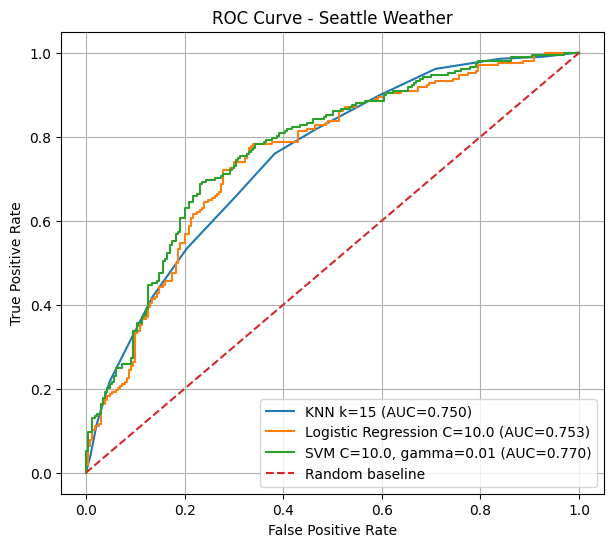

,Dataset,Model,AUC,Accuracy,Classification Error,Precision,Recall,F1-score
0,Australian Weather,KNN k=5,0.800485,0.829722,0.170278,0.677007,0.459727,0.547601
1,Australian Weather,Logistic Regression C=10.0,0.865203,0.846944,0.153056,0.721453,0.516729,0.602166
2,Australian Weather,"SVM C=10.0, gamma=0.1",0.841093,0.831667,0.168333,0.644604,0.555143,0.596538
3,Seattle Weather,KNN k=15,0.750042,0.678082,0.321918,0.661836,0.658654,0.660241
4,Seattle Weather,Logistic Regression C=10.0,0.753198,0.700913,0.299087,0.708108,0.629808,0.666667
5,Seattle Weather,"SVM C=10.0, gamma=0.01",0.769983,0.730594,0.269406,0.729592,0.687500,0.707921


In [63]:
# Build best model settings for ROC-AUC analysis
best_model_settings = []

for dataset_name in datasets.keys():
    # Best KNN from earlier experiment
    best_knn = knn_results_df[knn_results_df["Dataset"] == dataset_name].sort_values("F1-score", ascending=False).iloc[0]
    best_model_settings.append({
        "Dataset": dataset_name,
        "Model": f"KNN k={int(best_knn['k'])}",
        "Estimator": KNeighborsClassifier(n_neighbors=int(best_knn["k"])),
        "Normalize": best_knn["Normalized"] == "Yes"
    })

    # Best Logistic Regression from tuning
    best_log = logistic_tuning_df[logistic_tuning_df["Dataset"] == dataset_name].sort_values("F1-score", ascending=False).iloc[0]
    best_model_settings.append({
        "Dataset": dataset_name,
        "Model": f"Logistic Regression C={best_log['C']}",
        "Estimator": LogisticRegression(C=float(best_log["C"]), max_iter=2000, random_state=42),
        "Normalize": True
    })

    # Best SVM from tuning; probability=True is needed for probability-based ROC curve
    best_svm = svm_tuning_df[svm_tuning_df["Dataset"] == dataset_name].sort_values("F1-score", ascending=False).iloc[0]
    gamma_value = best_svm["gamma"]
    gamma_value = "scale" if gamma_value == "scale" else float(gamma_value)
    best_model_settings.append({
        "Dataset": dataset_name,
        "Model": f"SVM C={best_svm['C']}, gamma={best_svm['gamma']}",
        "Estimator": SVC(kernel="rbf", C=float(best_svm["C"]), gamma=gamma_value, probability=True, random_state=42),
        "Normalize": True
    })

roc_auc_results = []

for dataset_name, (X, y) in datasets.items():
    plt.figure(figsize=(7, 6))

    for setting in [s for s in best_model_settings if s["Dataset"] == dataset_name]:
        metrics, pipeline, X_test, y_test, y_pred = evaluate_pipeline_once(
            dataset_name=dataset_name,
            X=X,
            y=y,
            model_name=setting["Model"],
            model=setting["Estimator"],
            normalize=setting["Normalize"]
        )

        y_score = get_score_values(pipeline, X_test)
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"{setting['Model']} (AUC={roc_auc:.3f})")

        roc_auc_results.append({
            "Dataset": dataset_name,
            "Model": setting["Model"],
            "AUC": roc_auc,
            **metrics
        })

    plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
    plt.title(f"ROC Curve - {dataset_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True)
    plt.show()

roc_auc_df = pd.DataFrame(roc_auc_results)
roc_auc_df[["Dataset", "Model", "AUC", "Accuracy", "Classification Error", "Precision", "Recall", "F1-score"]]


### 9.4 Cross Validation

The previous evaluations use one 70:30 train/test split. To make the evaluation more reliable, Stratified k-fold Cross Validation is added. This method trains and evaluates each model on multiple folds while preserving the class distribution in each fold.

The table reports the mean and standard deviation of F1-score across folds.


In [64]:
# Stratified Cross Validation for best KNN, tuned Logistic Regression, and tuned SVM
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cross_validation_results = []

for dataset_name, (X, y) in datasets.items():
    for setting in [s for s in best_model_settings if s["Dataset"] == dataset_name]:
        # For CV, probability=True is not necessary for SVM when scoring by F1.
        estimator = setting["Estimator"]
        if isinstance(estimator, SVC):
            estimator = SVC(
                kernel="rbf",
                C=estimator.C,
                gamma=estimator.gamma,
                probability=False,
                random_state=42
            )

        pipeline = Pipeline(steps=[
            ("preprocessor", build_preprocessor(X, normalize=setting["Normalize"])),
            ("classifier", estimator)
        ])

        scores = cross_val_score(
            pipeline,
            X,
            y,
            cv=cv,
            scoring="f1",
            n_jobs=-1
        )

        cross_validation_results.append({
            "Dataset": dataset_name,
            "Model": setting["Model"],
            "CV Mean F1-score": scores.mean(),
            "CV Std F1-score": scores.std(),
            "Fold scores": np.round(scores, 4)
        })

cv_results_df = pd.DataFrame(cross_validation_results)
cv_results_df


,Dataset,Model,CV Mean F1-score,CV Std F1-score,Fold scores
0,Australian Weather,KNN k=5,0.527864,0.028077,"[0.542, 0.4737, 0.5442, 0.5283, 0.5511]"
1,Australian Weather,Logistic Regression C=10.0,0.594218,0.010213,"[0.5894, 0.5797, 0.6009, 0.5915, 0.6096]"
2,Australian Weather,"SVM C=10.0, gamma=0.1",0.597567,0.011128,"[0.605, 0.5787, 0.5956, 0.6118, 0.5967]"
3,Seattle Weather,KNN k=15,0.636961,0.013156,"[0.6431, 0.6246, 0.6207, 0.6394, 0.657]"
4,Seattle Weather,Logistic Regression C=10.0,0.645395,0.022191,"[0.6764, 0.6232, 0.6377, 0.6231, 0.6667]"
5,Seattle Weather,"SVM C=10.0, gamma=0.01",0.676118,0.028979,"[0.6982, 0.6458, 0.6475, 0.6691, 0.72]"


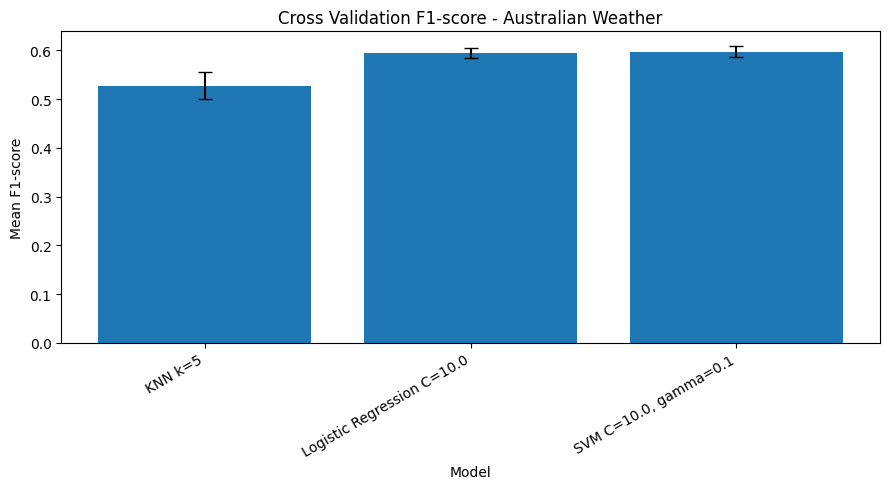

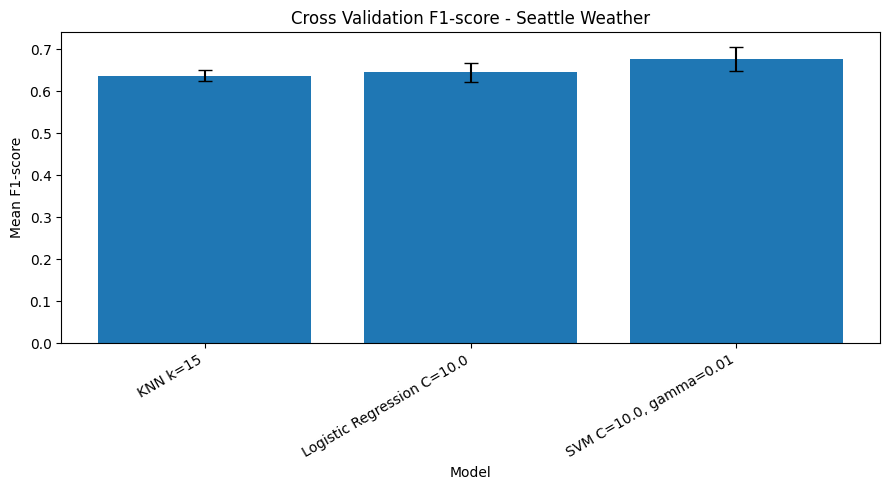

In [65]:
# Plot Cross Validation mean F1-score by model
for dataset_name in datasets.keys():
    subset = cv_results_df[cv_results_df["Dataset"] == dataset_name].copy()

    plt.figure(figsize=(9, 5))
    plt.bar(subset["Model"], subset["CV Mean F1-score"], yerr=subset["CV Std F1-score"], capsize=5)
    plt.title(f"Cross Validation F1-score - {dataset_name}")
    plt.xlabel("Model")
    plt.ylabel("Mean F1-score")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


### 9.5 Confusion Matrix Analysis of Best Tuned Models

The following table is designed for report Section **4.8 – Confusion Matrix Analysis of Best Tuned Models**.  
For each dataset, the best tuned model is selected based on the highest test F1-score among the tuned KNN, Logistic Regression, and SVM models.  
The confusion matrix is then decomposed into **TN, FP, FN, and TP**, together with additional diagnostic indicators such as specificity, false positive rate, and false negative rate.


In [66]:
# Confusion Matrix Analysis of Best Tuned Models
# This table can be used directly in report Section 4.8.

from IPython.display import display

confusion_analysis_rows = []

# Select the best tuned model for each dataset using the highest test F1-score from ROC-AUC analysis.
# roc_auc_df was created in the ROC Curve and AUC section.
best_tuned_models_df = (
    roc_auc_df
    .sort_values(["Dataset", "F1-score"], ascending=[True, False])
    .groupby("Dataset", as_index=False)
    .first()
)

for _, best_row in best_tuned_models_df.iterrows():
    dataset_name = best_row["Dataset"]
    best_model_name = best_row["Model"]

    # Find the estimator configuration corresponding to the selected tuned model.
    setting = next(
        s for s in best_model_settings
        if s["Dataset"] == dataset_name and s["Model"] == best_model_name
    )

    X, y = datasets[dataset_name]

    metrics, pipeline, X_test, y_test, y_pred = evaluate_pipeline_once(
        dataset_name=dataset_name,
        X=X,
        y=y,
        model_name=setting["Model"],
        model=setting["Estimator"],
        normalize=setting["Normalize"]
    )

    # Confusion matrix layout:
    # [[TN, FP],
    #  [FN, TP]]
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
    false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0

    # AUC from best_row if available.
    auc_value = best_row["AUC"] if "AUC" in best_row.index else np.nan

    confusion_analysis_rows.append({
        "Dataset": dataset_name,
        "Best Tuned Model": best_model_name,
        "Normalized": "Yes" if setting["Normalize"] else "No",
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "Accuracy": metrics["Accuracy"],
        "Classification Error": metrics["Classification Error"],
        "Precision": metrics["Precision"],
        "Recall / Sensitivity": metrics["Recall"],
        "Specificity": specificity,
        "False Positive Rate": false_positive_rate,
        "False Negative Rate": false_negative_rate,
        "F1-score": metrics["F1-score"],
        "AUC": auc_value
    })

confusion_matrix_analysis_df = pd.DataFrame(confusion_analysis_rows)

# Round numeric columns for academic report readability.
numeric_cols = [
    "Accuracy", "Classification Error", "Precision", "Recall / Sensitivity",
    "Specificity", "False Positive Rate", "False Negative Rate", "F1-score", "AUC"
]
confusion_matrix_analysis_df[numeric_cols] = confusion_matrix_analysis_df[numeric_cols].round(4)

display(confusion_matrix_analysis_df)


,Dataset,Best Tuned Model,Normalized,TN,FP,FN,TP,Accuracy,Classification Error,Precision,Recall / Sensitivity,Specificity,False Positive Rate,False Negative Rate,F1-score,AUC
0,Australian Weather,Logistic Regression C=10.0,Yes,2632,161,390,417,0.8469,0.1531,0.7215,0.5167,0.9424,0.0576,0.4833,0.6022,0.8652
1,Seattle Weather,"SVM C=10.0, gamma=0.01",Yes,177,53,65,143,0.7306,0.2694,0.7296,0.6875,0.7696,0.2304,0.3125,0.7079,0.7700


**Interpretation guide for Section 4.8**

- **TN (True Negative)**: number of correctly predicted no-rain cases.  
- **FP (False Positive)**: number of no-rain cases incorrectly predicted as rain.  
- **FN (False Negative)**: number of rainy cases incorrectly predicted as no rain.  
- **TP (True Positive)**: number of correctly predicted rainy cases.  
- **Recall / Sensitivity** is important for rainfall prediction because it measures how many actual rainy days are detected.  
- **Specificity** measures how well the model identifies no-rain days.  
- **False Negative Rate** is especially important because missed rain predictions may be more costly in practical forecasting.


### 9.6 Extended analysis

The hyperparameter tuning results provide a more complete comparison than using default parameters only. KNN is tuned by changing `k`, Logistic Regression is tuned by changing `C`, and SVM is tuned by changing both `C` and `gamma`. ROC-AUC adds another perspective by measuring how well models separate the two classes across different classification thresholds. Cross Validation further checks whether the chosen models are stable across multiple train/test folds.

These additions make the notebook more suitable for an academic machine learning report because they demonstrate model selection, model evaluation, and model validation.


## 10. Academic discussion and conclusion

This lab used two labeled weather datasets to perform supervised binary classification.  
The task was to predict whether it would rain tomorrow. Both datasets were split into training and testing subsets using a 70/30 ratio with stratification, so the rain/no-rain class distribution was preserved in both subsets.

KNN was evaluated using multiple values of `k`. The results show that the value of `k` can significantly affect performance. Smaller values of `k` are more sensitive to noise, while larger values of `k` produce smoother decision boundaries but may underfit if the value is too large.

Normalization is important for distance-based and margin-based models. KNN relies directly on distance, while SVM is also affected by feature scale. Therefore, normalized data usually gives more reliable results for these models. Logistic Regression can also benefit from normalization because it helps the optimization process converge more stably.

Overall, the best model should be selected based on the F1-score because the rain prediction task may have imbalanced classes. Accuracy alone can be misleading if the number of no-rain samples is much larger than the number of rain samples. Precision, recall, and F1-score provide a more complete view of model quality.